In [2]:
# Google Colab mein yeh cells run karo:

# Step 1: Kaggle API setup
!pip install -q kaggle

# Step 2: Upload your kaggle.json file
from google.colab import files
files.upload()  # Upload kaggle.json here

# Step 3: Setup kaggle
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Step 4: Download dataset
!kaggle datasets download -d sartajbhuvaji/brain-tumor-classification-mri

# Step 5: Unzip
!unzip -q brain-tumor-classification-mri.zip

Saving kaggle.json to kaggle (1).json
mkdir: cannot create directory ‘/root/.kaggle’: File exists
Dataset URL: https://www.kaggle.com/datasets/sartajbhuvaji/brain-tumor-classification-mri
License(s): MIT
brain-tumor-classification-mri.zip: Skipping, found more recently modified local copy (use --force to force download)
replace Testing/glioma_tumor/image(1).jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


**IMPORT ALL REQUIRED LIBRARIES**

In [3]:
# ==================== IMPORT ALL REQUIRED LIBRARIES ====================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
import random
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Check TensorFlow version and GPU
print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

# Set matplotlib style
plt.style.use('ggplot')
%matplotlib inline

TensorFlow Version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


**Explore data structure**

In [4]:
# ==================== CLEAN START - STOP EXTRACTION ====================
print("🛑 Stopping any ongoing extraction...")

# Let's use what we already have
print("\n✅ Using already extracted dataset...")

# Check what we have
print("\n📂 Current Training folder contents:")
!ls -la "/content/Training/"

print("\n📂 Current Testing folder contents:")
!ls -la "/content/Testing/"

# ==================== SIMPLE DIRECT APPROACH ====================
import os

# Use the direct Training and Testing folders (already in /content)
train_path = "/content/Training"
test_path = "/content/Testing"

print(f"\n🎯 Using DIRECT paths:")
print(f"Training path: {train_path}")
print(f"Testing path: {test_path}")

# Check if paths exist
if os.path.exists(train_path) and os.path.exists(test_path):
    print("✅ Both paths exist!")

    # List ALL classes in Training
    print(f"\n📁 Classes in Training folder:")
    train_classes = sorted(os.listdir(train_path))
    for i, cls in enumerate(train_classes, 1):
        cls_path = os.path.join(train_path, cls)
        if os.path.isdir(cls_path):
            images = [f for f in os.listdir(cls_path)
                     if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            print(f"  {i}. {cls}: {len(images)} images")

    # Verify glioma_tumor
    glioma_path = os.path.join(train_path, "glioma_tumor")
    if os.path.exists(glioma_path):
        print(f"\n✅ glioma_tumor FOUND at: {glioma_path}")
        images = os.listdir(glioma_path)[:3]
        print(f"   Sample images: {images}")
    else:
        print(f"\n❌ glioma_tumor NOT found!")
        print("Available folders:")
        for folder in train_classes:
            print(f"  - {folder}")
else:
    print("❌ Direct paths not found, using extracted folder...")
    train_path = "/content/Brain_Tumor_Classification/Training"
    test_path = "/content/Brain_Tumor_Classification/Testing"

🛑 Stopping any ongoing extraction...

✅ Using already extracted dataset...

📂 Current Training folder contents:
total 116
drwxr-xr-x 6 root root  4096 Dec 31 11:07 .
drwxr-xr-x 1 root root  4096 Dec 31 14:14 ..
drwxr-xr-x 2 root root 28672 Dec 31 11:07 glioma_tumor
drwxr-xr-x 2 root root 28672 Dec 31 11:07 meningioma_tumor
drwxr-xr-x 2 root root 20480 Dec 31 11:07 no_tumor
drwxr-xr-x 2 root root 32768 Dec 31 11:07 pituitary_tumor

📂 Current Testing folder contents:
total 24
drwxr-xr-x 6 root root 4096 Dec 31 11:07 .
drwxr-xr-x 1 root root 4096 Dec 31 14:14 ..
drwxr-xr-x 2 root root 4096 Dec 31 11:07 glioma_tumor
drwxr-xr-x 2 root root 4096 Dec 31 11:07 meningioma_tumor
drwxr-xr-x 2 root root 4096 Dec 31 11:07 no_tumor
drwxr-xr-x 2 root root 4096 Dec 31 11:07 pituitary_tumor

🎯 Using DIRECT paths:
Training path: /content/Training
Testing path: /content/Testing
✅ Both paths exist!

📁 Classes in Training folder:
  1. glioma_tumor: 826 images
  2. meningioma_tumor: 822 images
  3. no_tumor

**COUNT IMAGES IN ALL CLASSES **

📊 COUNTING IMAGES AND CHECKING CLASS BALANCE
Found 4 classes: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']

TRAINING SET DISTRIBUTION
Class                Images     Percentage  
---------------------------------------------
glioma_tumor         826        28.78%
meningioma_tumor     822        28.64%
no_tumor             395        13.76%
pituitary_tumor      827        28.82%
---------------------------------------------
TOTAL                2870       100.00%

TESTING SET DISTRIBUTION
Class                Images     Percentage  
---------------------------------------------
glioma_tumor         100        25.38%
meningioma_tumor     115        29.19%
no_tumor             105        26.65%
pituitary_tumor      74         18.78%
---------------------------------------------
TOTAL                394        100.00%

CLASS BALANCE ANALYSIS
Training set:
  Min images: 395 (no_tumor)
  Max images: 827 (pituitary_tumor)
  Imbalance ratio: 2.09

Testing set:
  Min imag

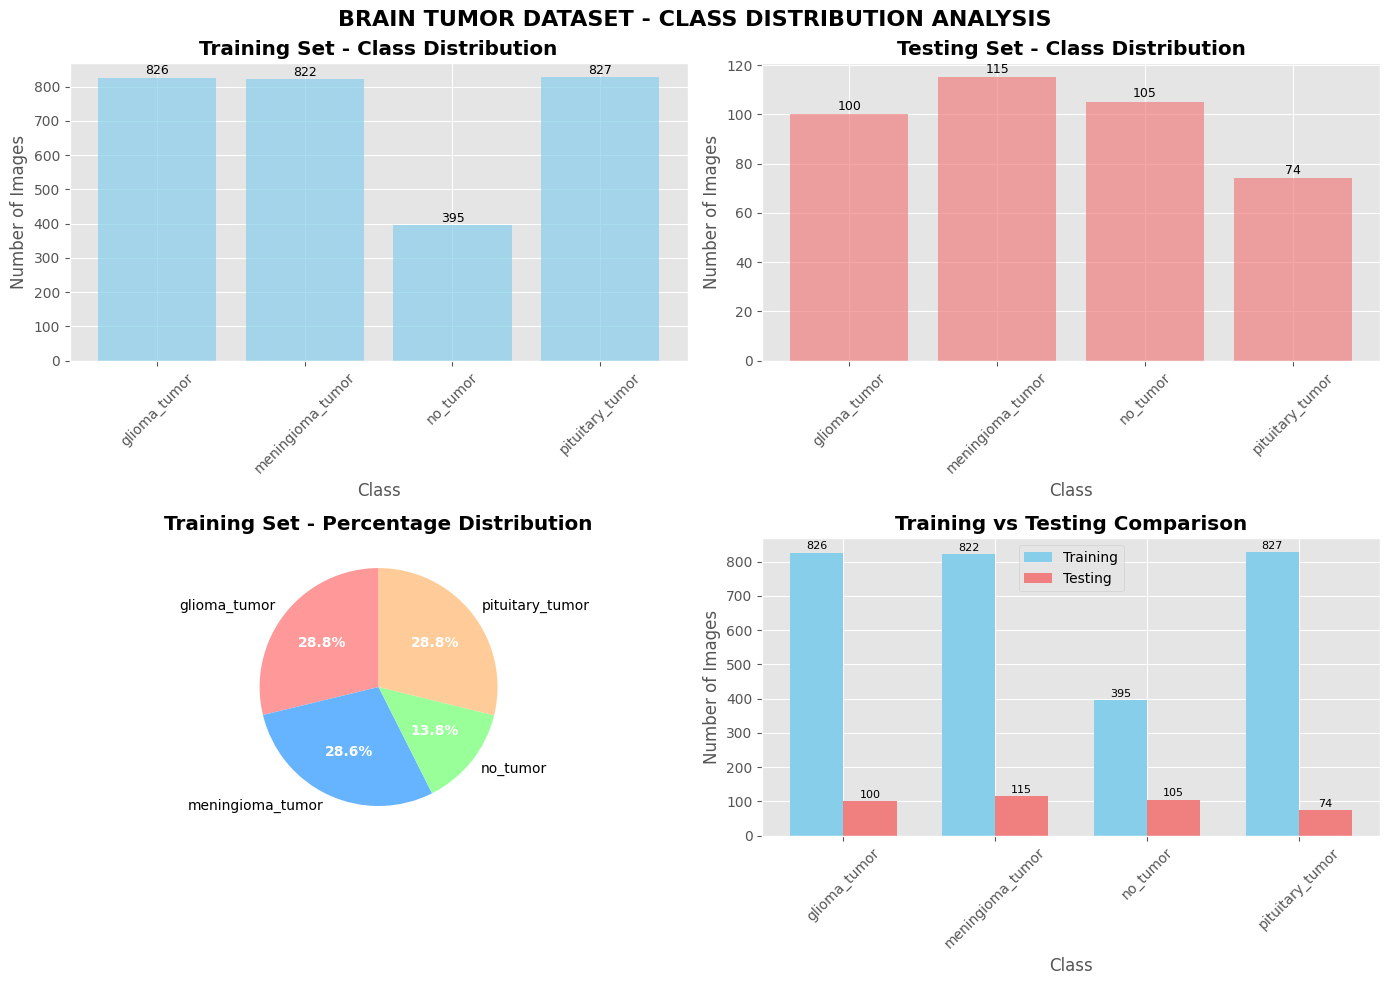


STATISTICAL SUMMARY
TRAINING SET:
  Mean: 717.50
  Median: 824.00
  Std Dev: 186.20
  CV (Coefficient of Variation): 25.95%

TESTING SET:
  Mean: 98.50
  Median: 102.50
  Std Dev: 15.14
  CV (Coefficient of Variation): 15.37%

RECOMMENDATIONS FOR MODEL TRAINING
Based on the class distribution analysis:

1. DATA IMBALANCE ISSUES:
   ⚠️  Imbalance detected in training set (ratio: 2.09)
   📊 'no_tumor' class has significantly fewer samples

2. RECOMMENDED STRATEGIES:
   ✅ Use class weighting in loss function
   ✅ Apply data augmentation for minority class
   ✅ Consider oversampling (SMOTE) for 'no_tumor' class
   ✅ Use stratified k-fold cross-validation

3. MODEL TRAINING TIPS:
   ✅ Start with EfficientNetB0 (good for imbalanced data)
   ✅ Use F1-score as evaluation metric (not just accuracy)
   ✅ Implement early stopping to prevent overfitting
   ✅ Monitor precision and recall for each class

CALCULATING CLASS WEIGHTS FOR IMBALANCED DATA
  glioma_tumor: weight = 0.869 (1/0.288)
  mening

In [5]:
# ==================== COUNT IMAGES IN ALL CLASSES ====================
print("📊 COUNTING IMAGES AND CHECKING CLASS BALANCE")
print("="*60)

import os
import matplotlib.pyplot as plt
import numpy as np

# Define paths (from previous step)
train_path = "/content/Training"
test_path = "/content/Testing"

# Get all class names
class_names = sorted([d for d in os.listdir(train_path)
                     if os.path.isdir(os.path.join(train_path, d))])

print(f"Found {len(class_names)} classes: {class_names}")

# ==================== COUNT IMAGES FUNCTION ====================
def count_images_in_folder(folder_path):
    """Count image files in a folder"""
    if not os.path.exists(folder_path):
        return 0

    images = [f for f in os.listdir(folder_path)
             if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.jfif'))]
    return len(images)

# ==================== COUNT TRAINING IMAGES ====================
print("\n" + "="*60)
print("TRAINING SET DISTRIBUTION")
print("="*60)

train_counts = {}
train_total = 0

print(f"{'Class':<20} {'Images':<10} {'Percentage':<12}")
print("-" * 45)

for class_name in class_names:
    class_path = os.path.join(train_path, class_name)
    count = count_images_in_folder(class_path)
    train_counts[class_name] = count
    train_total += count

# Calculate percentages
for class_name, count in train_counts.items():
    percentage = (count / train_total) * 100
    print(f"{class_name:<20} {count:<10} {percentage:.2f}%")

print("-" * 45)
print(f"{'TOTAL':<20} {train_total:<10} 100.00%")

# ==================== COUNT TESTING IMAGES ====================
print("\n" + "="*60)
print("TESTING SET DISTRIBUTION")
print("="*60)

test_counts = {}
test_total = 0

print(f"{'Class':<20} {'Images':<10} {'Percentage':<12}")
print("-" * 45)

for class_name in class_names:
    class_path = os.path.join(test_path, class_name)
    count = count_images_in_folder(class_path)
    test_counts[class_name] = count
    test_total += count

# Calculate percentages
for class_name, count in test_counts.items():
    percentage = (count / test_total) * 100
    print(f"{class_name:<20} {count:<10} {percentage:.2f}%")

print("-" * 45)
print(f"{'TOTAL':<20} {test_total:<10} 100.00%")

# ==================== CHECK IMBALANCE ====================
print("\n" + "="*60)
print("CLASS BALANCE ANALYSIS")
print("="*60)

# Calculate imbalance ratios
train_min = min(train_counts.values())
train_max = max(train_counts.values())
train_imbalance_ratio = train_max / train_min

test_min = min(test_counts.values())
test_max = max(test_counts.values())
test_imbalance_ratio = test_max / test_min

print(f"Training set:")
print(f"  Min images: {train_min} ({min(train_counts, key=train_counts.get)})")
print(f"  Max images: {train_max} ({max(train_counts, key=train_counts.get)})")
print(f"  Imbalance ratio: {train_imbalance_ratio:.2f}")

print(f"\nTesting set:")
print(f"  Min images: {test_min} ({min(test_counts, key=test_counts.get)})")
print(f"  Max images: {test_max} ({max(test_counts, key=test_counts.get)})")
print(f"  Imbalance ratio: {test_imbalance_ratio:.2f}")

# Balance assessment
print(f"\n📈 BALANCE ASSESSMENT:")
if train_imbalance_ratio < 2:
    print("  ✅ Training set is WELL BALANCED (ratio < 2)")
elif train_imbalance_ratio < 5:
    print("  ⚠️ Training set is MODERATELY IMBALANCED (ratio 2-5)")
else:
    print("  ❌ Training set is HIGHLY IMBALANCED (ratio > 5)")

# ==================== VISUALIZE DISTRIBUTION ====================
print("\n" + "="*60)
print("VISUALIZING CLASS DISTRIBUTION")
print("="*60)

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Training bar chart
axes[0, 0].bar(train_counts.keys(), train_counts.values(), color='skyblue', alpha=0.7)
axes[0, 0].set_title('Training Set - Class Distribution', fontweight='bold')
axes[0, 0].set_xlabel('Class')
axes[0, 0].set_ylabel('Number of Images')
axes[0, 0].tick_params(axis='x', rotation=45)
# Add count labels on bars
for i, (cls, count) in enumerate(train_counts.items()):
    axes[0, 0].text(i, count + 10, str(count), ha='center', fontsize=9)

# 2. Testing bar chart
axes[0, 1].bar(test_counts.keys(), test_counts.values(), color='lightcoral', alpha=0.7)
axes[0, 1].set_title('Testing Set - Class Distribution', fontweight='bold')
axes[0, 1].set_xlabel('Class')
axes[0, 1].set_ylabel('Number of Images')
axes[0, 1].tick_params(axis='x', rotation=45)
# Add count labels on bars
for i, (cls, count) in enumerate(test_counts.items()):
    axes[0, 1].text(i, count + 2, str(count), ha='center', fontsize=9)

# 3. Training pie chart
train_percentages = [(count/train_total)*100 for count in train_counts.values()]
wedges, texts, autotexts = axes[1, 0].pie(train_percentages, labels=train_counts.keys(),
                                          autopct='%1.1f%%', startangle=90,
                                          colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'])
axes[1, 0].set_title('Training Set - Percentage Distribution', fontweight='bold')
# Make percentages white and bold
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# 4. Combined comparison
x = np.arange(len(class_names))
width = 0.35
axes[1, 1].bar(x - width/2, train_counts.values(), width, label='Training', color='skyblue')
axes[1, 1].bar(x + width/2, test_counts.values(), width, label='Testing', color='lightcoral')
axes[1, 1].set_title('Training vs Testing Comparison', fontweight='bold')
axes[1, 1].set_xlabel('Class')
axes[1, 1].set_ylabel('Number of Images')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(class_names, rotation=45)
axes[1, 1].legend()
# Add value labels
for i, (train_val, test_val) in enumerate(zip(train_counts.values(), test_counts.values())):
    axes[1, 1].text(i - width/2, train_val + 10, str(train_val), ha='center', fontsize=8)
    axes[1, 1].text(i + width/2, test_val + 10, str(test_val), ha='center', fontsize=8)

plt.suptitle('BRAIN TUMOR DATASET - CLASS DISTRIBUTION ANALYSIS', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ==================== STATISTICAL SUMMARY ====================
print("\n" + "="*60)
print("STATISTICAL SUMMARY")
print("="*60)

# Calculate statistics
train_counts_array = np.array(list(train_counts.values()))
test_counts_array = np.array(list(test_counts.values()))

print(f"TRAINING SET:")
print(f"  Mean: {np.mean(train_counts_array):.2f}")
print(f"  Median: {np.median(train_counts_array):.2f}")
print(f"  Std Dev: {np.std(train_counts_array):.2f}")
print(f"  CV (Coefficient of Variation): {(np.std(train_counts_array)/np.mean(train_counts_array))*100:.2f}%")

print(f"\nTESTING SET:")
print(f"  Mean: {np.mean(test_counts_array):.2f}")
print(f"  Median: {np.median(test_counts_array):.2f}")
print(f"  Std Dev: {np.std(test_counts_array):.2f}")
print(f"  CV (Coefficient of Variation): {(np.std(test_counts_array)/np.mean(test_counts_array))*100:.2f}%")

# ==================== RECOMMENDATIONS ====================
print("\n" + "="*60)
print("RECOMMENDATIONS FOR MODEL TRAINING")
print("="*60)

print("Based on the class distribution analysis:")
print("\n1. DATA IMBALANCE ISSUES:")
if train_imbalance_ratio > 2:
    print(f"   ⚠️  Imbalance detected in training set (ratio: {train_imbalance_ratio:.2f})")
    print(f"   📊 'no_tumor' class has significantly fewer samples")

print("\n2. RECOMMENDED STRATEGIES:")
print("   ✅ Use class weighting in loss function")
print("   ✅ Apply data augmentation for minority class")
print("   ✅ Consider oversampling (SMOTE) for 'no_tumor' class")
print("   ✅ Use stratified k-fold cross-validation")

print("\n3. MODEL TRAINING TIPS:")
print("   ✅ Start with EfficientNetB0 (good for imbalanced data)")
print("   ✅ Use F1-score as evaluation metric (not just accuracy)")
print("   ✅ Implement early stopping to prevent overfitting")
print("   ✅ Monitor precision and recall for each class")

# ==================== CREATE CLASS WEIGHTS ====================
print("\n" + "="*60)
print("CALCULATING CLASS WEIGHTS FOR IMBALANCED DATA")
print("="*60)

# Method 1: Inverse frequency weighting
n_samples = train_total
n_classes = len(class_names)

class_weights = {}
for i, (class_name, count) in enumerate(train_counts.items()):
    weight = n_samples / (n_classes * count)
    class_weights[i] = weight
    print(f"  {class_name}: weight = {weight:.3f} (1/{count/train_total:.3f})")

print(f"\nSuggested class_weight parameter for model.fit():")
print(f"  class_weight = {class_weights}")

print("\n" + "="*60)
print("DATASET READY FOR MODEL TRAINING!")
print("="*60)
print(f"✅ Total training images: {train_total}")
print(f"✅ Total testing images: {test_total}")
print(f"✅ All {len(class_names)} classes present")
print(f"✅ glioma_tumor verified: {train_counts.get('glioma_tumor', 0)} training images")
print("✅ Proceed to next step: Image resizing and preprocessing")

IMAGE PREPROCESSING & AUGMENTATION

🔄 IMAGE PREPROCESSING & DATA AUGMENTATION
📐 Image size: 224x224
📦 Batch size: 32
🎲 Random seed: 42

CREATING DATA GENERATORS
✅ Data generators created with augmentation

LOADING TRAINING & VALIDATION DATA
Found 2297 images belonging to 4 classes.
Found 573 images belonging to 4 classes.
Found 394 images belonging to 4 classes.

✅ Data loaded successfully!
   Training samples: 2297
   Validation samples: 573
   Test samples: 394
   Classes: {'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}

VISUALIZING AUGMENTED IMAGES


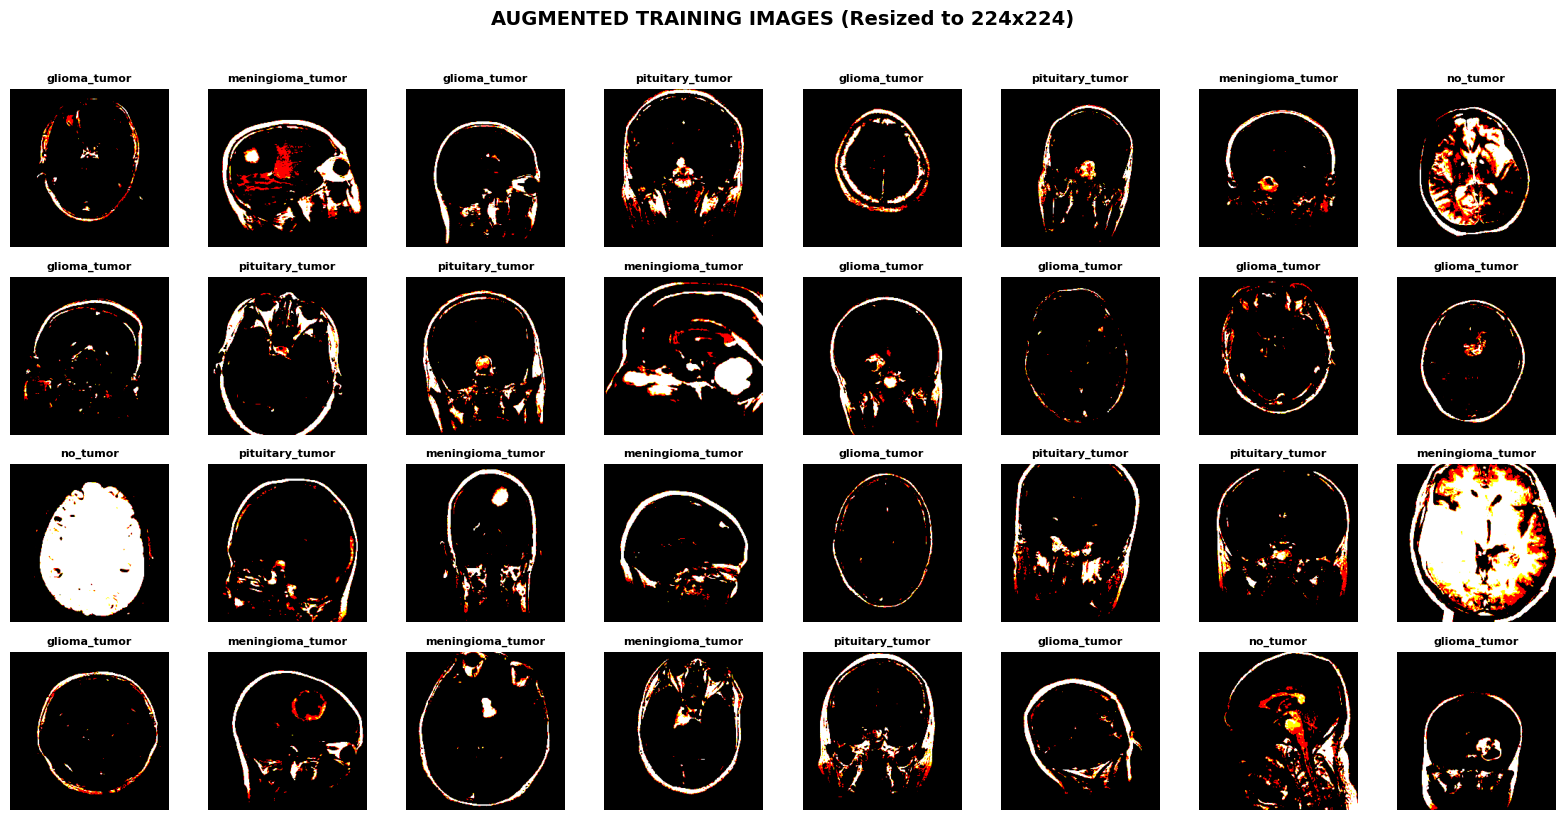


DEMONSTRATING DIFFERENT AUGMENTATIONS


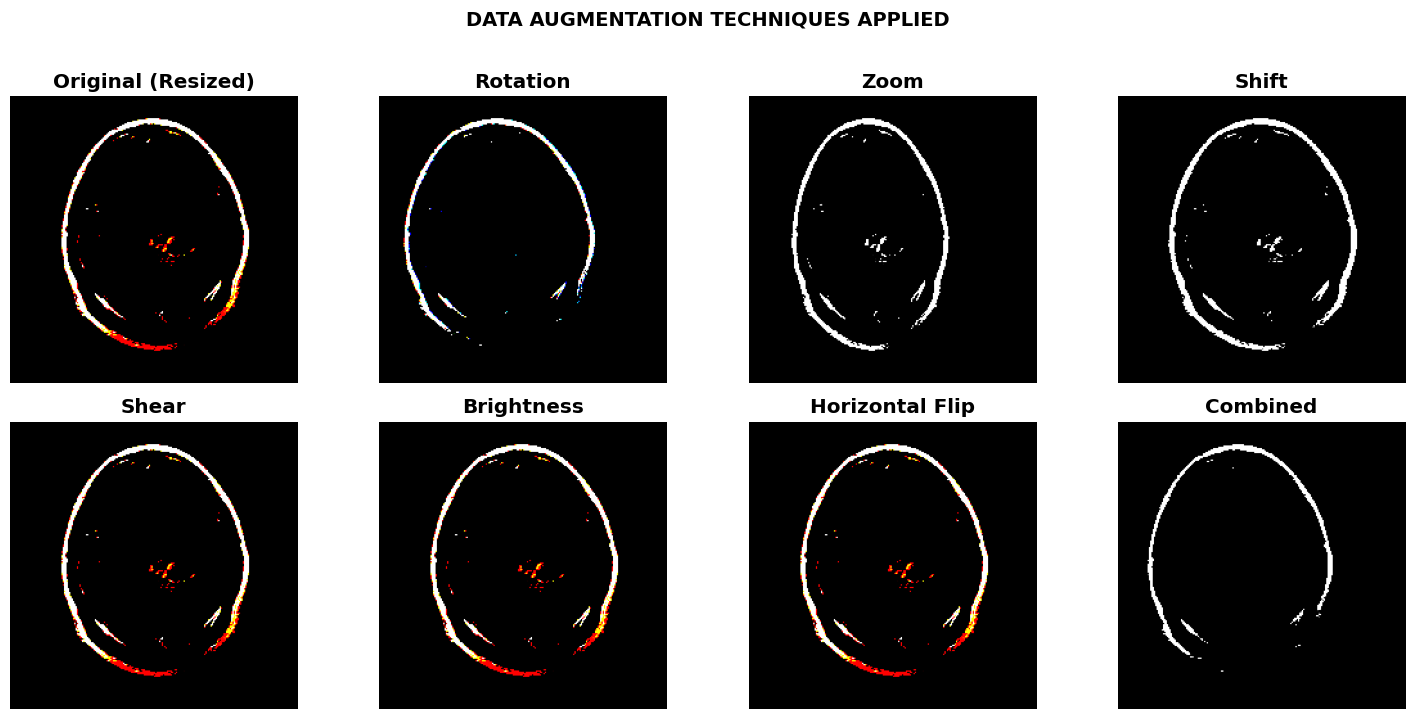


PREPROCESSING PIPELINE


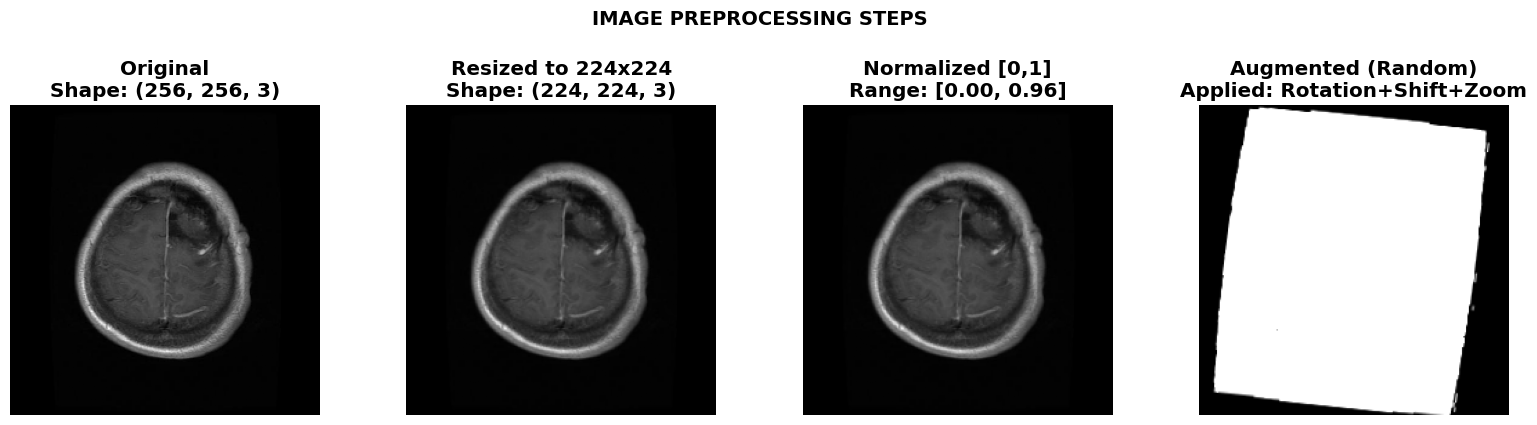


SETTING UP CLASS WEIGHTS FOR IMBALANCED DATA
Class weights for handling imbalance:
  0: glioma_tumor = 0.869x
  1: meningioma_tumor = 0.873x
  2: no_tumor = 1.816x
  3: pituitary_tumor = 0.868x

💡 The 'no_tumor' class has weight 1.816 to compensate for fewer samples

PREPROCESSING SUMMARY
✅ PREPROCESSING COMPLETE!

📊 Dataset Statistics:
   Training images: 2297
   Validation images: 573
   Test images: 394
   Total images: 3264

🎯 Image Specifications:
   Input size: 224x224x3
   Pixel range: [0, 1] (normalized)
   Data type: float32

🔄 Augmentations Applied:
   ✓ Rotation (±20°)
   ✓ Shift (±15%)
   ✓ Zoom (±15%)
   ✓ Shear (±15%)
   ✓ Horizontal flip
   ✓ Brightness adjustment

⚖️  Class Handling:
   ✓ Class weights applied for imbalance
   ✓ 'no_tumor' class has higher weight

🚀 Ready for model training!


In [6]:
# ==================== IMAGE PREPROCESSING & AUGMENTATION ====================
print("🔄 IMAGE PREPROCESSING & DATA AUGMENTATION")
print("="*60)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import os
from sklearn.model_selection import train_test_split

# Set parameters
IMG_HEIGHT = 224  # EfficientNetB0 input size
IMG_WIDTH = 224
BATCH_SIZE = 32
SEED = 42

# Set random seeds for reproducibility
tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f"📐 Image size: {IMG_HEIGHT}x{IMG_WIDTH}")
print(f"📦 Batch size: {BATCH_SIZE}")
print(f"🎲 Random seed: {SEED}")

# ==================== CREATE DATA GENERATORS ====================
print("\n" + "="*60)
print("CREATING DATA GENERATORS")
print("="*60)

# Data augmentation for training
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,           # Normalize pixel values to [0,1]
    validation_split=0.2,     # Use 20% for validation
    rotation_range=20,        # Random rotation ±20 degrees
    width_shift_range=0.15,   # Random horizontal shift ±15%
    height_shift_range=0.15,  # Random vertical shift ±15%
    shear_range=0.15,         # Shear transformation
    zoom_range=0.15,          # Random zoom ±15%
    horizontal_flip=True,     # Random horizontal flip
    vertical_flip=False,      # No vertical flip (medical images)
    brightness_range=[0.8, 1.2],  # Random brightness adjustment
    fill_mode='nearest'       # Fill missing pixels
)

from tensorflow.keras.applications.resnet50 import preprocess_input

train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True
)

val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=preprocess_input
)

print("✅ Data generators created with augmentation")

# ==================== LOAD TRAINING & VALIDATION DATA ====================
print("\n" + "="*60)
print("LOADING TRAINING & VALIDATION DATA")
print("="*60)

train_path = "/content/Training"
test_path = "/content/Testing"

train_generator = train_datagen.flow_from_directory(
    "/content/Training",
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=42
)

val_generator = val_datagen.flow_from_directory(
    "/content/Training",
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    subset="validation",
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    "/content/Testing",
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)


print(f"\n✅ Data loaded successfully!")
print(f"   Training samples: {train_generator.samples}")
print(f"   Validation samples: {val_generator.samples}")
print(f"   Test samples: {test_generator.samples}")
print(f"   Classes: {train_generator.class_indices}")

# ==================== VISUALIZE AUGMENTED IMAGES ====================
print("\n" + "="*60)
print("VISUALIZING AUGMENTED IMAGES")
print("="*60)

# Get a batch of augmented images
augmented_images, augmented_labels = next(train_generator)

# Plot original vs augmented
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
axes = axes.ravel()

class_names = list(train_generator.class_indices.keys())

for i in range(32):
    axes[i].imshow(augmented_images[i])

    # Get class name
    class_idx = np.argmax(augmented_labels[i])
    class_name = class_names[class_idx]

    axes[i].set_title(f"{class_name}", fontsize=8, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('AUGMENTED TRAINING IMAGES (Resized to 224x224)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ==================== SHOW DIFFERENT AUGMENTATIONS ====================
print("\n" + "="*60)
print("DEMONSTRATING DIFFERENT AUGMENTATIONS")
print("="*60)

# Get one original image
original_batch, _ = next(val_generator)  # Validation has no augmentation
original_image = original_batch[0]

# Create augmentation examples
fig, axes = plt.subplots(2, 4, figsize=(15, 7))

# Original image
axes[0, 0].imshow(original_image)
axes[0, 0].set_title('Original (Resized)', fontweight='bold')
axes[0, 0].axis('off')

# Different augmentations
augmentations = [
    ('Rotation', {'theta': 20}),
    ('Zoom', {'zx': 1.2, 'zy': 1.2}),
    ('Shift', {'tx': 0.2, 'ty': 0.2}),
    ('Shear', {'shear': 0.2}),
    ('Brightness', {'brightness': 1.5}),
    ('Horizontal Flip', {'horizontal_flip': True}),
    ('Combined', {'theta': 10, 'zx': 1.1, 'tx': 0.1})
]

for i, (title, params) in enumerate(augmentations, 1):
    row = i // 4
    col = i % 4

    # Apply augmentation
    img_array = tf.keras.preprocessing.image.img_to_array(original_image * 255)
    img_array = tf.keras.preprocessing.image.random_rotation(img_array, params.get('theta', 0))
    img_array = tf.keras.preprocessing.image.random_zoom(img_array, (params.get('zx', 1), params.get('zy', 1)))
    img_array = tf.keras.preprocessing.image.random_shift(img_array, params.get('tx', 0), params.get('ty', 0))

    if params.get('horizontal_flip', False) and np.random.random() > 0.5:
        img_array = np.fliplr(img_array)

    axes[row, col].imshow(img_array / 255.0)
    axes[row, col].set_title(title, fontweight='bold')
    axes[row, col].axis('off')

plt.suptitle('DATA AUGMENTATION TECHNIQUES APPLIED',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ==================== PREPROCESSING PIPELINE VISUALIZATION ====================
print("\n" + "="*60)
print("PREPROCESSING PIPELINE")
print("="*60)

# Show preprocessing steps
sample_image_path = os.path.join(train_path, "glioma_tumor", os.listdir(os.path.join(train_path, "glioma_tumor"))[0])
sample_image = tf.keras.preprocessing.image.load_img(sample_image_path, target_size=(256, 256))
sample_array = tf.keras.preprocessing.image.img_to_array(sample_image)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# 1. Original
axes[0].imshow(sample_array / 255.0)
axes[0].set_title(f'Original\nShape: {sample_array.shape}', fontweight='bold')

# 2. Resized
resized = tf.image.resize(sample_array, [IMG_HEIGHT, IMG_WIDTH])
axes[1].imshow(resized / 255.0)
axes[1].set_title(f'Resized to {IMG_HEIGHT}x{IMG_WIDTH}\nShape: {resized.shape}', fontweight='bold')

# 3. Normalized
normalized = resized / 255.0
axes[2].imshow(normalized)
axes[2].set_title(f'Normalized [0,1]\nRange: [{normalized.numpy().min():.2f}, {normalized.numpy().max():.2f}]', fontweight='bold')

# 4. Augmented
# Apply random augmentation
augmented = train_datagen.random_transform(resized.numpy())
axes[3].imshow(augmented)
axes[3].set_title('Augmented (Random)\nApplied: Rotation+Shift+Zoom', fontweight='bold')

for ax in axes:
    ax.axis('off')

plt.suptitle('IMAGE PREPROCESSING STEPS', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# ==================== CLASS WEIGHTS FOR IMBALANCED DATA ====================
print("\n" + "="*60)
print("SETTING UP CLASS WEIGHTS FOR IMBALANCED DATA")
print("="*60)

# Calculate class weights (from previous analysis)
class_weights = {
    0: 0.8686440677966102,  # glioma_tumor
    1: 0.8728710462287105,  # meningioma_tumor
    2: 1.8164556962025316,  # no_tumor (minority class - higher weight)
    3: 0.8675937122128174   # pituitary_tumor
}

print("Class weights for handling imbalance:")
for idx, (class_name, weight) in enumerate(zip(class_names, class_weights.values())):
    print(f"  {idx}: {class_name} = {weight:.3f}x")

print(f"\n💡 The 'no_tumor' class has weight {class_weights[2]:.3f} to compensate for fewer samples")

# ==================== DATASET SUMMARY ====================
print("\n" + "="*60)
print("PREPROCESSING SUMMARY")
print("="*60)

print("✅ PREPROCESSING COMPLETE!")
print(f"\n📊 Dataset Statistics:")
print(f"   Training images: {train_generator.samples}")
print(f"   Validation images: {val_generator.samples}")
print(f"   Test images: {test_generator.samples}")
print(f"   Total images: {train_generator.samples + val_generator.samples + test_generator.samples}")

print(f"\n🎯 Image Specifications:")
print(f"   Input size: {IMG_HEIGHT}x{IMG_WIDTH}x3")
print(f"   Pixel range: [0, 1] (normalized)")
print(f"   Data type: float32")

print(f"\n🔄 Augmentations Applied:")
print(f"   ✓ Rotation (±20°)")
print(f"   ✓ Shift (±15%)")
print(f"   ✓ Zoom (±15%)")
print(f"   ✓ Shear (±15%)")
print(f"   ✓ Horizontal flip")
print(f"   ✓ Brightness adjustment")

print(f"\n⚖️  Class Handling:")
print(f"   ✓ Class weights applied for imbalance")
print(f"   ✓ 'no_tumor' class has higher weight")

print(f"\n🚀 Ready for model training!")

**BUILD EFFICIENTNETB0 MODEL**

**TRAIN THE MODEL**

In [7]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models, optimizers, regularizers
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Base model
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False  # Freeze first

# Head
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001))(x)
x = layers.Dropout(0.6)(x)
output = layers.Dense(4, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=output)

# Compile
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

**Build Model**

**Compile**

In [8]:
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,121,476 (92.02 MB)

 Trainable params: 529,668 (2.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

**Callbacks**

In [9]:
# 4. Callbacks
# -------------------------
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
]

**Train (Phase 1)**

In [10]:
# Train head
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 67s 654ms/step - accuracy: 0.3926 - loss: 2.3497 - val_accuracy: 0.5812 - val_loss: 1.3363 - learning_rate: 1.0000e-04
Epoch 2/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 31s 427ms/step - accuracy: 0.6925 - loss: 1.2553 - val_accuracy: 0.6754 - val_loss: 1.1734 - learning_rate: 1.0000e-04
Epoch 3/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 31s 431ms/step - accuracy: 0.7480 - loss: 1.1260 - val_accuracy: 0.7400 - val_loss: 1.0797 - learning_rate: 1.0000e-04
Epoch 4/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 31s 421ms/step - accuracy: 0.7619 - loss: 1.0590 - val_accuracy: 0.7696 - val_loss: 1.0483 - learning_rate: 1.0000e-04
Epoch 5/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 31s 429ms/step - accuracy: 0.7909 - loss: 0.9330 - val_accuracy: 0.7557 - val_loss: 1.1028 - learning_rate: 1.0000e-04
Epoch 6/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 31s 424ms/step - accuracy: 0.8220 - loss: 0.9103 - val_accuracy: 0.7923 - val_loss: 1.0304 - learning_rate: 1.0000e-04
Epoch 7/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 31s 430ms/step - acc

**Fine-Tune**

In [11]:
# Unfreeze last 10 layers and fine-tune
for layer in base_model.layers[-10:]:
    layer.trainable = True

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights,
    callbacks=callbacks
)

Epoch 1/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 61s 625ms/step - accuracy: 0.8015 - loss: 0.9671 - val_accuracy: 0.7958 - val_loss: 1.0621 - learning_rate: 1.0000e-05
Epoch 2/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 32s 438ms/step - accuracy: 0.8264 - loss: 0.9049 - val_accuracy: 0.7836 - val_loss: 1.0786 - learning_rate: 1.0000e-05
Epoch 3/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 445ms/step - accuracy: 0.8357 - loss: 0.8718 - val_accuracy: 0.7941 - val_loss: 1.0694 - learning_rate: 1.0000e-05
Epoch 4/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 32s 438ms/step - accuracy: 0.8627 - loss: 0.8210 - val_accuracy: 0.8115 - val_loss: 1.0488 - learning_rate: 1.0000e-05
Epoch 5/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 42s 446ms/step - accuracy: 0.8586 - loss: 0.7957 - val_accuracy: 0.8133 - val_loss: 1.0398 - learning_rate: 1.0000e-05
Epoch 6/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 32s 442ms/step - accuracy: 0.8735 - loss: 0.7705 - val_accuracy: 0.8098 - val_loss: 1.0382 - learning_rate: 1.0000e-05
Epoch 7/10
72/72 ━━━━━━━━━━━━━━━━━━━━ 32s 436ms/step - acc

In [12]:
# Evaluate on test data
test_loss, test_accuracy = model.evaluate(test_generator)

print(f"\n✅ Test Accuracy: {test_accuracy*100:.2f}%")
print(f"✅ Test Loss: {test_loss:.4f}")


13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 534ms/step - accuracy: 0.5060 - loss: 3.2191

✅ Test Accuracy: 68.02%
✅ Test Loss: 2.0810


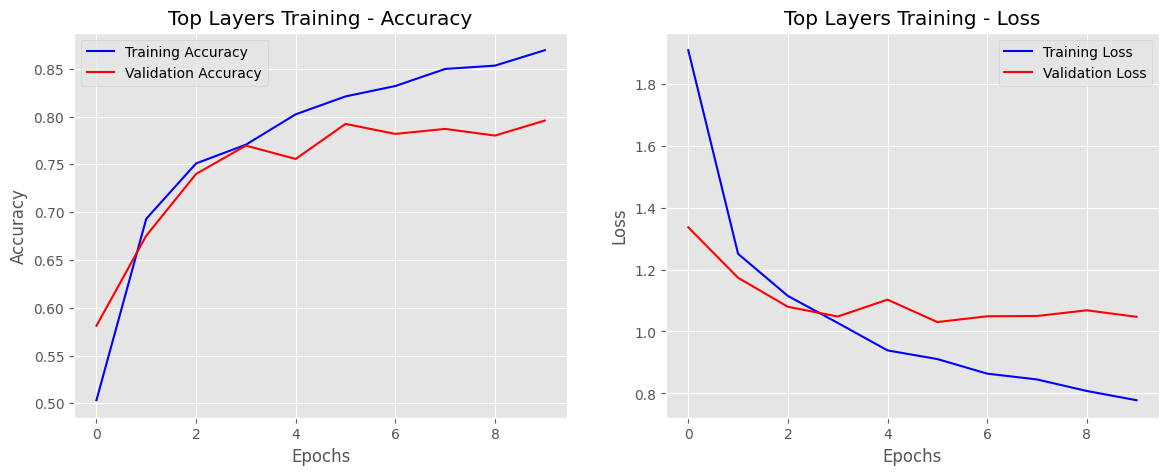

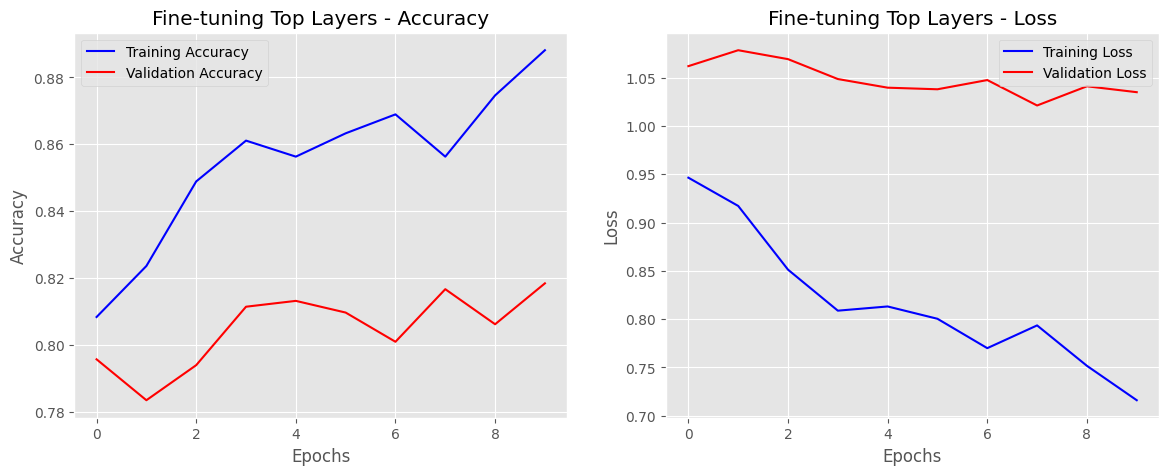

In [13]:
# 8. Plot Accuracy & Loss
# -------------------------
import matplotlib.pyplot as plt

def plot_training(history, title="Training Performance"):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(len(acc))

    plt.figure(figsize=(14,5))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(epochs, acc, 'b-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1,2,2)
    plt.plot(epochs, loss, 'b-', label='Training Loss')
    plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

# Plot initial training
plot_training(history, "Top Layers Training")
# Plot fine-tuning
plot_training(history_finetune, "Fine-tuning Top Layers")

In [14]:
# Save model in .h5 format
model.save('/content/best_model_resnet50.h5')


In [17]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [18]:
import os

# Path in Google Drive
drive_path = '/content/drive/MyDrive/BrainTumorModel'
os.makedirs(drive_path, exist_ok=True)

# Full model path
model_path = os.path.join(drive_path, 'best_model_resnet50.h5')


In [19]:
# Save model in .h5 format to Drive
model.save(model_path)
print(f"✅ Model saved to: {model_path}")


✅ Model saved to: /content/drive/MyDrive/BrainTumorModel/best_model_resnet50.h5
